# ==================== BLOCK 1: LIBRARY IMPORTS ====================


In [ ]:
import pandas as pd
import numpy as np
import gc
import optuna # Hyperparameter optimization framework
from optuna.samplers import TPESampler
from datetime import datetime as dt
from datetime import date
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import operator
warnings.filterwarnings("ignore")  # Suppress warnings for cleaner output
# MLflow is configured after environment setup - important for experiment logging
import mlflow
mlflow.set_tracking_uri("http://localhost:5000")
# Hydrology-specific libraries
import hydroeval as he
from lumod import tools
from lumod.models import HBV

/home/cluster/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# ==================== BLOCK 2: EARLY STOPPING CALLBACK ====================
# This class implements early stopping for Optuna trials
# It stops optimization if the metric doesn't improve for a specified number of rounds

In [2]:
class EarlyStoppingCallback(object):
    """Early stopping callback for Optuna."""

    def __init__(self, early_stopping_rounds: int, direction: str = "minimize") -> None:
        self.early_stopping_rounds = early_stopping_rounds

        self._iter = 0

        if direction == "minimize":
            self._operator = operator.lt
            self._score = np.inf
        elif direction == "maximize":
            self._operator = operator.gt
            self._score = -np.inf
        else:
            ValueError(f"invalid direction: {direction}")

    def __call__(self, study: optuna.Study, trial: optuna.Trial) -> None:
        """Do early stopping."""
        if self._operator(study.best_value, self._score):
            self._iter = 0
            self._score = study.best_value
        else:
            self._iter += 1

        if self._iter >= self.early_stopping_rounds:
            study.stop()

# ==================== BLOCK 3: DATA LOADING FUNCTIONS ====================
# These helper functions extract hydrological and meteorological data for a specific gauge station.

In [5]:
def get_q_data_on_index(index_hydro, hydro_data):
    hydro_data = hydro_data.loc[hydro_data["index"] == index_hydro]
    hydro_data['Date'] = pd.to_datetime(hydro_data['date'])
    hydro_data.set_index("date", inplace=True)
    hydro_data = hydro_data.rename(columns={"q": "qt"})
    recharge_data = hydro_data["qt"]
    return recharge_data

In [6]:
def get_hydro_data_on_index(index_hydro):
    hydro_meteo_data = pd.read_excel(f"data/catchiments/{index_hydro}.xlsx")
    hydro_meteo_data['Date'] = pd.to_datetime(hydro_meteo_data['Date'])
    hydro_meteo_data['Prec'] = hydro_meteo_data['Prec'].fillna(0)
    hydro_meteo_data.set_index("Date", inplace=True)
    hydro_meteo_data = hydro_meteo_data.rename(columns={"Temp": "tmean", "Prec": "prec"})
    hydro_meteo_data = hydro_meteo_data[["prec", "tmean"]]
    return hydro_meteo_data

In [7]:
def get_post_info(df, index):
    df = df.loc[df["ids"] == index]
    area = float(df['Площ'])
    lat = float(df['lat'])
    return area, lat

# ==================== LOAD DATA FILES ====================
# Load the main data files containing discharge records and station metadata.

In [ ]:
hydro_q_data = pd.read_excel("data/qtpet_pairs.xlsx")
hydro_post_data = pd.read_excel("data/hydrology_stations.xlsx")

In [ ]:
index_hydro = 11188

In [ ]:
# Extract discharge data
hydro_q_data = get_q_data_on_index(index_hydro, hydro_q_data)

In [ ]:
# Extract meteorological data and then add the discharge data to it
hydro_data = get_hydro_data_on_index(index_hydro)
hydro_data["qt"] = hydro_q_data

In [ ]:
print(list(hydro_data.asfreq(freq='D').index.difference(hydro_data.index)))

[Timestamp('2003-11-20 00:00:00')]


In [ ]:
hydro_data

,prec,tmean,qt
Date,,,
1995-01-01,0.147687,-4.976246,NaN
1995-01-02,0.002140,-9.578138,NaN
1995-01-03,0.000000,-11.277353,NaN
1995-01-04,0.152332,-5.826610,NaN
1995-01-05,5.090416,-1.672636,NaN
...,...,...,...
2025-12-27,0.129283,-16.946551,NaN
2025-12-28,0.035291,-16.633325,NaN
2025-12-29,0.000852,-11.680672,NaN


# ====================  SET UP MLFLOW EXPERIMENT ====================
# Create or retrieve an MLflow experiment to track all calibration runs.
# The experiment name includes the station name, ID, optimization method, and calibration period.

In [12]:
mlflow.set_experiment(f"{hydro_post_data.loc[hydro_post_data["ids"] == index_hydro]["name"].values[0]}({index_hydro}) NEW RMSE TPE v1. 2012 по 2021")

<Experiment: artifact_location='s3://mlflow-artifacts/100', creation_time=1775666118508, experiment_id='100', last_update_time=1775666118508, lifecycle_stage='active', name='р. Красноярка – с.Предгорное(11188) NEW RMSE TPE v1. 2012 по 2021', tags={}>

# ==================== MODEL OBJECTIVE FUNCTION ====================
# This is the core function that Optuna will call to evaluate each set of parameters.
# It runs the HBV model with given parameters, calculates performance metrics, and logs them to MLflow.

In [ ]:
def model_objective(trial, area, lat, date_start_minus_one, date_end, hydro_data):
    """Objective function for Optuna optimization.

    Args:
        trial: Optuna trial object for suggesting hyperparameters
        area (float): Catchment area (km²)
        lat (float): atitude
        date_start_minus_one (date): Start date for model run (one year before calibration start)
        date_end (date): End date for model run
        hydro_data (pd.DataFrame): DataFrame with precipitation, temperature, and observed discharge

    Returns:
        obj_metric: RMSE value to minimize
    """
    with mlflow.start_run() as _:
        parameters =  { 
                        # "maxbas": trial.suggest_int("maxbas", 1, 10, step = 1),
                        "tthres": trial.suggest_float("tthres", -2, 5, step = 0.5),
                        "dd": trial.suggest_float("dd", 1, 6, step=0.1),
                        "beta": trial.suggest_float("beta", 1, 6, step=0.1),
                        "fc": trial.suggest_int("fc", 10, 1000, step=10),
                        "k0":  trial.suggest_float("k0", 0.01, 9, step=0.02),
                        "k1": trial.suggest_float("k1", 0.001, 2, step=0.002),
                        "k2": trial.suggest_float("k2", 0.0001, 0.01, step=0.0002),
                        "kp": trial.suggest_float("kp", 0, 2, step = 0.05), # recession coefficient of percolation (1/d)
                        "snow0": trial.suggest_float("snow0", -10, 100, step=2),
                        "w01": trial.suggest_int("w01", 10, 900, step=10),
                        "w02": trial.suggest_int("w02", 10, 500, step=10),
                        # "lthres": trial.suggest_int("lthres", 10, 100, step=5),
                        # 'pwp': trial.suggest_float("pwp", 0.1, 1, step=0.1), # Soil permanente wilting point as a fraction of fc (-) [0,1]  
                        # "s0": trial.suggest_float("s0", 0.1, 1, step=0.1), # Initial soil moisture storage (s/fc) [0-1]
                        # "cevp": trial.suggest_float("cevp", 0.5, 30, step=0.5),# PET parameter that depends of land use (mm/day.°C)
                        # "cevpam": trial.suggest_float("cevpam", 0, 0.5, step=0.1),
                        # "cevpph": trial.suggest_int("cevpph", 0, 365, step=10),
                }
        # HBV init
        model_HBV = HBV(
            area=area,
            lat=lat,
            params=parameters)
        
        # start
        sim_HBV = model_HBV.run(hydro_data.loc[date_start_minus_one:date_end])
        df_hydro = pd.DataFrame()
        df_hydro["Observed values"] =  hydro_data.loc[date_start_minus_one:date_end].qt
        df_hydro["Simulated values"] =  sim_HBV.loc[date_start_minus_one:date_end].qt
        df_hydro = df_hydro[date_start_minus_one.replace(year=date_start_minus_one.year + 1):]
        df_hydro = df_hydro.dropna()
        df_hydro = df_hydro[df_hydro["Simulated values"] != np.inf]
        df_hydro = df_hydro[df_hydro["Simulated values"] > -np.inf]
        expected_years = set(range(date_start_minus_one.year+1 , date_end.year))
        years_in_data = df_hydro.index.year.unique()
        years_present = set(years_in_data)
        missing_years = expected_years - years_present
        if len(df_hydro) > 0 and not missing_years:
            mlflow.log_params(parameters)
            metrics = {
                "NSE" : float((he.evaluator(he.nse, df_hydro["Simulated values"].values, df_hydro["Observed values"].values))[0]), 
                "KGE": float((he.evaluator(he.kge, df_hydro["Simulated values"].values, df_hydro["Observed values"].values))[0]),
                "RMSE": root_mean_squared_error(df_hydro["Observed values"].values, df_hydro["Simulated values"].values),
                "MAE": mean_absolute_error(df_hydro["Observed values"].values, df_hydro["Simulated values"].values),
            }
            mlflow.log_metrics(metrics)
            obj_metric = metrics['RMSE']
            del model_HBV
            del sim_HBV
            gc.collect()
            return obj_metric
        return 100000

In [ ]:
# Define the time period for model calibration and validation.
start=date(2012, 1, 1)
end=date(2021, 12, 31)
# Get catchment characteristics for the selected gauge
area, lat = get_post_info(hydro_post_data, index_hydro)

# ==================== : OPTUNA OPTIMIZATION ====================
# Configure and run the hyperparameter optimization using Optuna.

In [ ]:
# Create early stopping callback (stop after 2000 trials without improvement)
early_stopping = EarlyStoppingCallback(2000, direction="minimize")
sampler_cma = TPESampler(seed=42, n_startup_trials=100, multivariate=True)
# Set Optuna logging to show only warnings (reduce verbosity)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(study_name="study",
                            direction="minimize",
                            sampler=sampler_cma)

# Run optimization with 5000 trials, 10 parallel jobs
study.optimize(
    lambda trial: model_objective(trial, area=area, lat=lat, date_start_minus_one=start, date_end = end, hydro_data = hydro_data),
    n_trials=5000,
    n_jobs=10,
    gc_after_trial=True,
    show_progress_bar=True,
    callbacks=[early_stopping]
)
best_calibration = study.best_trial.params

In [ ]:
# Display the optimal parameters found by Optuna.
study.best_trial.params

{'tthres': 0.5,
 'dd': 2.7,
 'beta': 3.2,
 'fc': 800,
 'k0': 0.03,
 'k1': 0.049,
 'k2': 0.0001,
 'kp': 0.15000000000000002,
 'snow0': 14.0,
 'w01': 310,
 'w02': 230}

# ==================== FINAL MODEL RUN WITH BEST PARAMETERS ====================
# Run the model one final time using the optimal parameters to generate simulation results.

In [ ]:
model_HBV = HBV(
    area=area,
    lat=lat,
    params=study.best_trial.params)

sim_HBV = model_HBV.run(hydro_data.loc[start:end])
df_hydro_calibration = pd.DataFrame()
df_hydro_calibration["Observed values"] =  hydro_data.loc[start:end].qt
df_hydro_calibration["Simulated values"] =  sim_HBV.loc[start:end].qt
df_hydro_calibration = df_hydro_calibration[start.replace(year=start.year + 1):]
df_hydro_calibration
df_hydro_calibration = df_hydro_calibration.dropna()
df_hydro_calibration = df_hydro_calibration[df_hydro_calibration["Simulated values"] != np.inf]
df_hydro_calibration = df_hydro_calibration[df_hydro_calibration["Simulated values"] > -np.inf]

In [18]:
df_hydro_calibration

,Observed values,Simulated values
Date,,
2013-01-01,0.78,0.275244
2013-01-02,0.80,0.275209
2013-01-03,0.83,0.275176
2013-01-04,0.86,0.275144
2013-01-05,0.89,0.275112
...,...,...
2021-12-27,1.46,2.075210
2021-12-28,1.43,2.073038
2021-12-29,1.40,2.071242


# ==================== SAVE RESULTS TO EXCEL ====================
# Export the calibration results to an Excel file for later analysis.

In [19]:
df_hydro_calibration.to_excel(f"result/{hydro_post_data.loc[hydro_post_data["ids"] == index_hydro]["name"].values[0]}({index_hydro}) NEW RMSE CMA v1. 2012 по 2021.xlsx")

In [ ]:
# Calculate performance metrics
metrics_calibration = {
        "NSE" : round(float((he.evaluator(he.nse, df_hydro_calibration["Simulated values"].values, df_hydro_calibration["Observed values"].values))[0]), 2), 
        "KGE": round(float((he.evaluator(he.kge, df_hydro_calibration["Simulated values"].values, df_hydro_calibration["Observed values"].values))[0]), 2),
        "RMSE": round(root_mean_squared_error(df_hydro_calibration["Observed values"].values, df_hydro_calibration["Simulated values"].values), 2),
        "MAE": round(mean_absolute_error(df_hydro_calibration["Observed values"].values, df_hydro_calibration["Simulated values"].values), 2),
    }
metrics_calibration = pd.DataFrame.from_dict([metrics_calibration])
metrics_calibration

,NSE,KGE,RMSE,MAE
0,0.52,0.67,3.06,1.76


# ==================== VISUALIZATION ====================
# Create comparative plots of observed vs simulated discharge for each year.

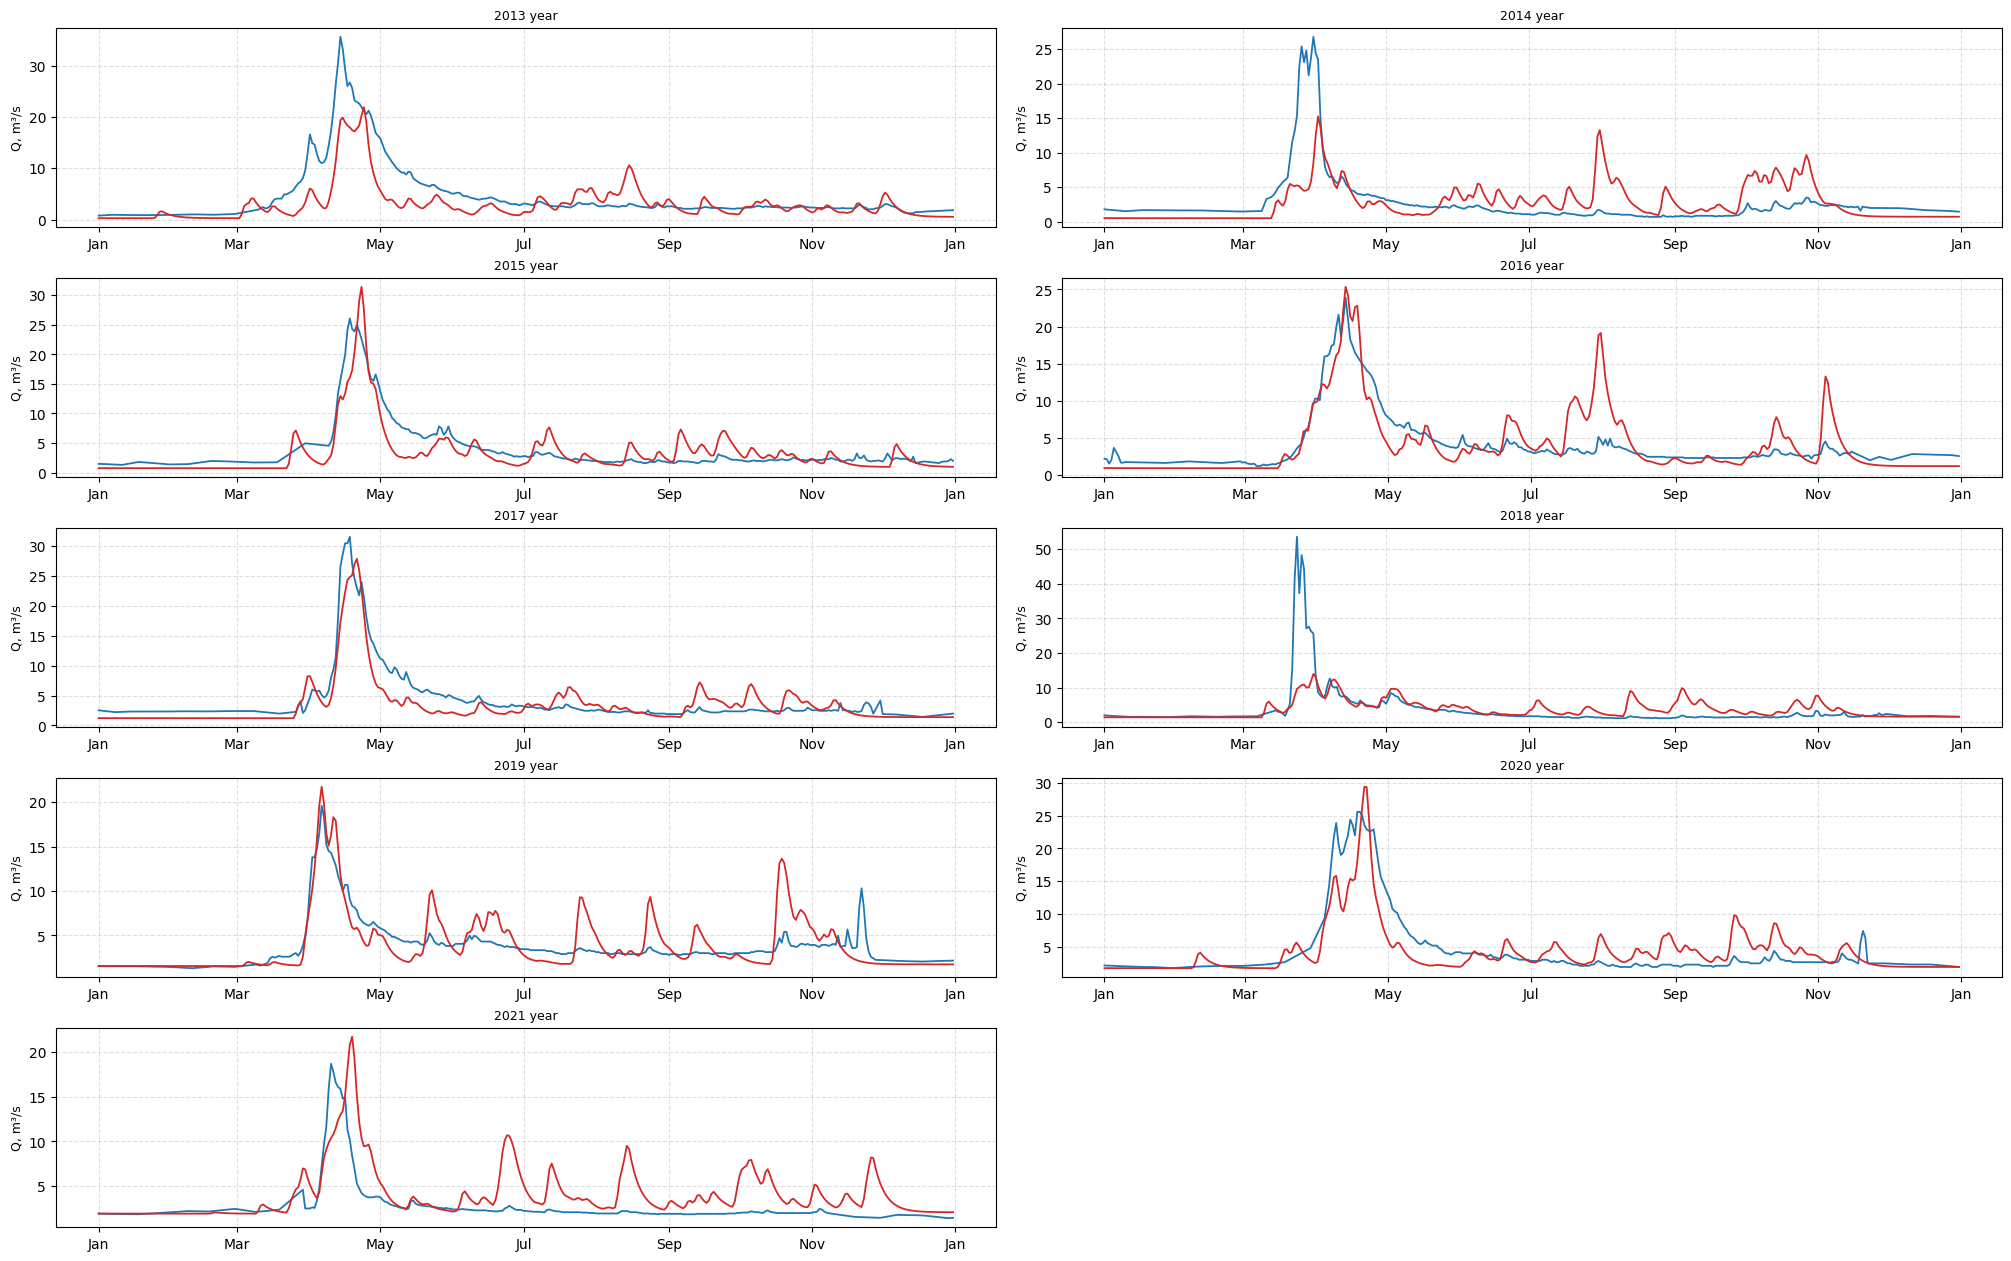

In [ ]:
numeric_cols = ['Observed values', 'Simulated values']
years = sorted(df_hydro_calibration.index.year.unique())

# Define subplot grid dimensions (2 columns, rows based on number of years)
ncols = 2
nrows = (len(years) + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, 
    figsize=(20, nrows*2.5), 
    constrained_layout=True
)

date_format = mdates.DateFormatter("%b")

lines = []
for col in numeric_cols:
    line, = axes.flat[0].plot([], [], label=col)
    lines.append(line)

for i, year in enumerate(years):
    ax = axes.flat[i]
    year_data = df_hydro_calibration[df_hydro_calibration.index.year == year]

    ax.plot(year_data['Observed values'], color="#1f77b4", linewidth=1.3)
    ax.plot(year_data['Simulated values'], color="#d62728", linewidth=1.3)
    ax.set_ylabel("Q, m³/s", fontsize=9)
    ax.set_title(f'{year} year', fontsize=9)
    ax.xaxis.set_major_formatter(date_format)
    ax.grid(True, linestyle='--', alpha=0.4)


for j in range(i+1, nrows*ncols):
    fig.delaxes(axes.flat[j])

plt.subplots_adjust(bottom=0.10)
plt.show()